# <center>Homework 95</center>

In [10]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from importlib import reload
import semi_supervised_alg

In [11]:
X, y = make_moons(n_samples=1000, noise=0.05)

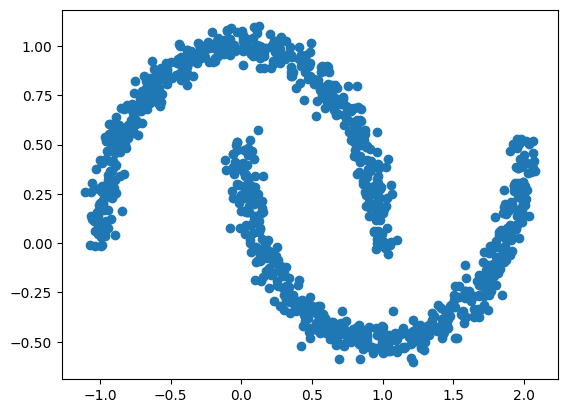

In [12]:
plt.scatter(X[:, 0], X[:, 1])

In [13]:
reload(semi_supervised_alg)
from semi_supervised_alg import DBSCAN

dbscan = DBSCAN(eps=0.2, min_samples=5).fit(X)

In [14]:
dbscan.labels_
dbscan.components_

array([[-0.56582768,  0.88637899],
       [ 0.03829075,  0.16742413],
       [-0.033464  ,  1.07243258],
       ...,
       [ 1.99623038,  0.30852415],
       [ 1.95700549,  0.30402416],
       [ 0.12307313,  1.098294  ]], shape=(1000, 2))

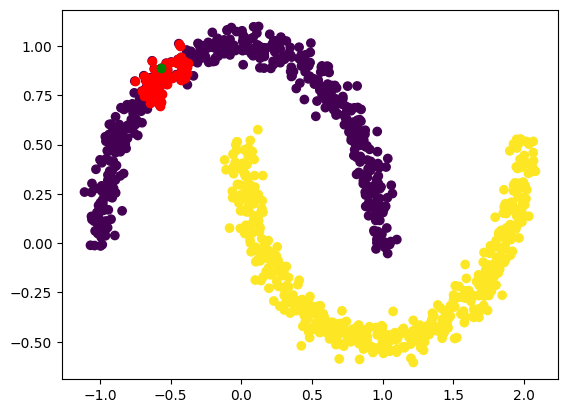

In [15]:
plt.scatter(X[:, 0], X[:, 1], c=dbscan.labels_)

i = 0
p = X[i]
p_neigh = dbscan.point_neighbors_inxs[i] 
plt.scatter(X[p_neigh, 0], X[p_neigh, 1], c='r')
plt.scatter(p[0], p[1], c='g')

In [16]:
reload(semi_supervised_alg)
from semi_supervised_alg import DBSCAN

dbscan = DBSCAN(eps=0.05, min_samples=5).fit(X)

In [17]:
(dbscan.labels_ == -1).sum()

np.int64(69)

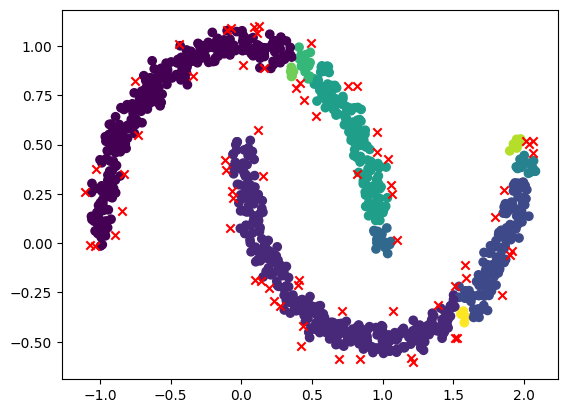

In [18]:
not_outlayers = dbscan.labels_ != -1
plt.scatter(X[not_outlayers, 0], X[not_outlayers, 1], c=dbscan.labels_[not_outlayers])

outlayers = ~not_outlayers
plt.scatter(X[outlayers, 0], X[outlayers, 1], c='r', marker='x')

In [19]:
custom_fitpred = dbscan.fit_predict(X)

In [20]:
dbscan.predict([[-1, 0.25]])
dbscan.predict([[-1, 1]])

array([-1.])

---

In [21]:
from sklearn.cluster import DBSCAN
dbscan_org = DBSCAN(0.2, min_samples=5).fit(X)

In [22]:
dbscan_org.components_

array([[-0.56582768,  0.88637899],
       [ 0.03829075,  0.16742413],
       [-0.033464  ,  1.07243258],
       ...,
       [ 1.99623038,  0.30852415],
       [ 1.95700549,  0.30402416],
       [ 0.12307313,  1.098294  ]], shape=(1000, 2))

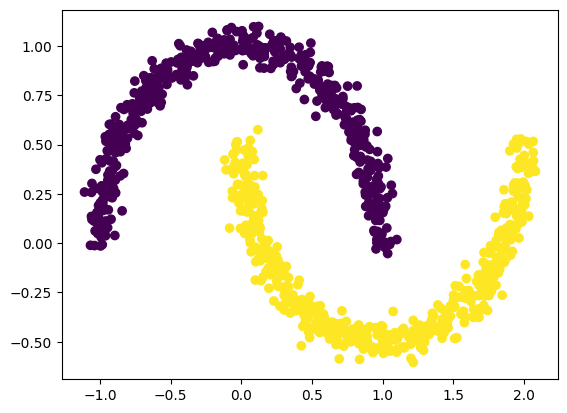

In [23]:
plt.scatter(X[:, 0], X[:, 1], c=dbscan_org.labels_)

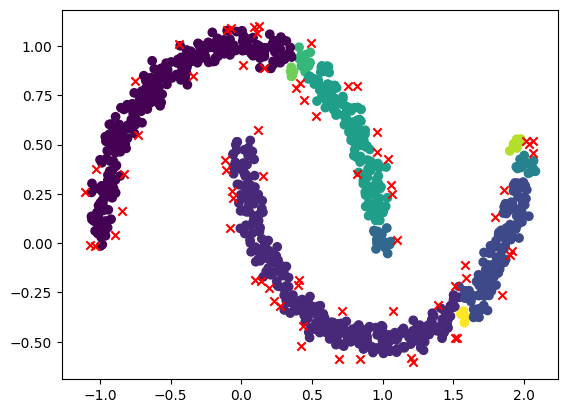

In [24]:
from sklearn.cluster import DBSCAN
dbscan_org = DBSCAN(0.05, min_samples=5).fit(X)

not_outlayers = dbscan_org.labels_ != -1
plt.scatter(X[not_outlayers, 0], X[not_outlayers, 1], c=dbscan_org.labels_[not_outlayers])

outlayers = ~not_outlayers
plt.scatter(X[outlayers, 0], X[outlayers, 1], c='r', marker='x')

In [25]:
original_fitpred = dbscan_org.fit_predict(X)

In [26]:
import numpy as np
(original_fitpred == custom_fitpred).sum()

np.int64(997)

## Task 2

да се генерира dataset с make_blobs, така че:
- клъстерите да са с различна големина
- накои от клъстерите да са елипсовидни
- да имат различна плътност
- да са с различен брой елементи
- да се добавят outlier-и, случайно генерирани inastance-и
- да се визуализира получения dataset
- ползвайки класа GaussianMixture да се открият всички клъстери и outlier-и

In [101]:
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture

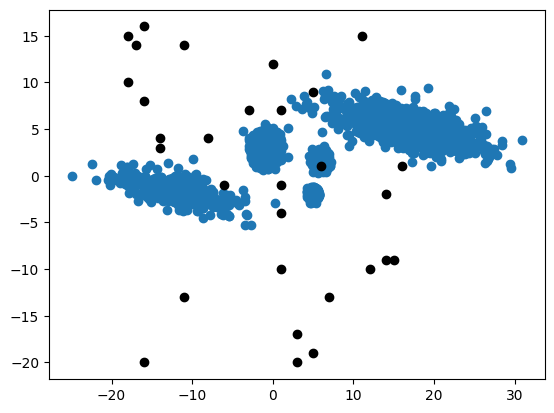

In [100]:
samples = [300, 500, 800, 400, 350]
stds = [1, 0.3, 1.2, 0.9, 0.5]
centers = [[-3, -4], [5, -2], [4.2, 8.5], [-1, 3], [6, 1.8]]

X, y = make_blobs(samples, centers=centers, cluster_std=stds, random_state=42)

transformation = np.array([
    [4, -0.8],
    [0,  1]
])

mask = (y == 0) | (y == 2)
X[mask] @= transformation
plt.scatter(X[:, 0], X[:, 1])

np.random.seed(43)
outlier = np.random.randint(-20, 20, (30, 2))
plt.scatter(outlier[:, 0], outlier[:, 1], c='black')

X = np.concatenate([X, outlier])
np.random.shuffle(X)

In [102]:
gm = GaussianMixture(5, n_init=10)
y_pred = gm.fit_predict(X)

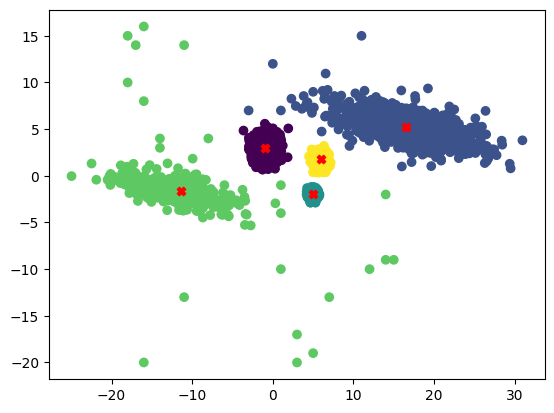

In [103]:
plt.scatter(X[:, 0], X[:, 1], c=y_pred)

centers = gm.means_
plt.scatter(centers[:, 0], centers[:, 1], marker='X', c='r')

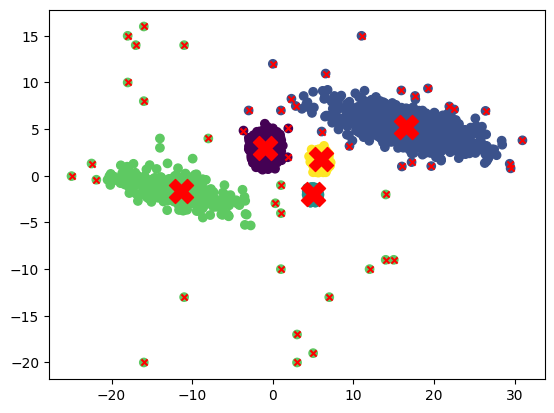

In [111]:
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 2)
anomalies = X[densities < density_threshold]

plt.scatter(X[:, 0], X[:, 1], c=y_pred)
centers = gm.means_
plt.scatter(centers[:, 0], centers[:, 1], marker='X', c='r', s=300)

plt.scatter(anomalies[:, 0], anomalies[:, 1], marker='x', c='r', s=20)

# <center>Exercises Chapter 9

1. How would you define clustering? Can you name a few clustering algorithms?

- групиране на данни според плътност/близот до подбрани групиращи инстанси (пр. центроиди) 
- KMeans; DBSCAN; Agglomerative clustering; Spectral clustering

2. What are some of the main applications of clustering algorithms?

- при unsupervised lerning и semi-supervised lerning 
- за откриване на подходящи лейбали на нелейбалнати данни 
- за откриване на групи в данните
- за обобщаване на данните
- откриване на аномалии

3. Describe two techniques to select the right number of clusters when using k-means.

пъров се правят експерименти с голям диапазон на K и се гледат
- диаграми със silhouette score и inertia спрямо всяко К
- избират се К около най висока стойност при silhouette score и най голяма чупка при inertia

- след намиране на приблизителна стойност за К се чертаят няколко silhouette diagram коя вече дава най голяма яснота

4. What is label propagation? Why would you implement it, and how?

- това е когато малка част от данните ни имат лейбали и със тях обучваме модел който да предсакаже лейбалите на останалите данни

5. Can you name two clustering algorithms that can scale to large datasets? And two
that look for regions of high density?

- MiniBatchKMeans
- DBSCAN 

6. Can you think of a use case where active learning would be useful? How would
you implement it?

- когато нямаме лейбалнати данни и изолзваме къстеринг за да намерим кои са най представителните семпли за всеки клъстер като ги подаваме на потребителя за да ни даде лейбали за тях след това обучаваме модел със тях и проверяваме неговия скор ако искам де го подобрим повтаряме процеса

7. What is the difference between anomaly detection and novelty detection?

- anomaly detection се обучава с данни в които може да има и отклнонения като целта му е да открие точно тези отклонения
- novelty detection се обучава само с чисти данни в които да няма outliers и вече да може да предсказва невиждани данни дали са outliers

8. What is a Gaussian mixture? What tasks can you use it for?

- вероятностен модел, който приема че данни са образувани като смес от няколко гаусови разпределения
- клъстеринг, откриване на аномалии, генериране на данни 

9. Can you name two techniques to find the right number of clusters when using a
Gaussian mixture model?

- Bayesian information criterion (BIC) and Akaike information criterion (AIC)

10. The classic Olivetti faces dataset contains 400 grayscale 64 × 64–pixel images of
faces. Each image is flattened to a 1D vector of size 4,096. Forty different people
were photographed (10 times each), and the usual task is to train a model that can predict which person is represented in each picture. Load the dataset using
the sklearn.datasets.fetch_olivetti_faces() function, then split it into a
training set, a validation set, and a test set (note that the dataset is already scaled
between 0 and 1). Since the dataset is quite small, you will probably want to
use stratified sampling to ensure that there are the same number of images per
person in each set. Next, cluster the images using k-means, and ensure that you
have a good number of clusters (using one of the techniques discussed in this
chapter). Visualize the clusters: do you see similar faces in each cluster?

In [164]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.neighbors import KNeighborsClassifier

In [267]:
X, y = fetch_olivetti_faces(return_X_y=True, shuffle=True, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42, shuffle=True)

X_train_mini, X_val, y_train_mini, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42, shuffle=True)

In [ ]:
plot_face = lambda img, ax: ax.imshow(img.reshape(64, 64), cmap='gray', vmin=0, vmax=1)
fig, ax = plt.subplots()
plot_face(X[300], ax)

In [149]:
# np.unique(y_train_mini, return_counts=True)
np.unique(y_val, return_counts=True)[1].sum()

np.int64(72)

In [150]:
silhouette_scores = []
inertials = []
k = np.arange(2, 71)

for i in k:
    kmeans = KMeans(i, random_state=42, n_init=2).fit(X_val)
    silhouette_scores.append(silhouette_score(X_val, kmeans.labels_))
    inertials.append(kmeans.inertia_)

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10))

ax[0].plot(k, inertials, marker='s', c='r')
ax[0].set_title('Inertia')
ax[0].grid()

ax[1].plot(k, silhouette_scores, marker='o', c='b')
ax[1].set_title('silhouette_scores')
ax[1].grid()

In [ ]:
kmeans = KMeans(40, random_state=42, n_init=2)
fig, ax = plt.subplots(figsize=(20, 18))
visualizer = SilhouetteVisualizer(kmeans, ax=ax).fit(X_train)
visualizer.show()

In [ ]:
kmeans = KMeans(22, random_state=42, n_init=2)
fig, ax = plt.subplots(figsize=(20, 18))
visualizer = SilhouetteVisualizer(kmeans, ax=ax).fit(X_train)
visualizer.show()

In [172]:
X_train.shape

(360, 4096)

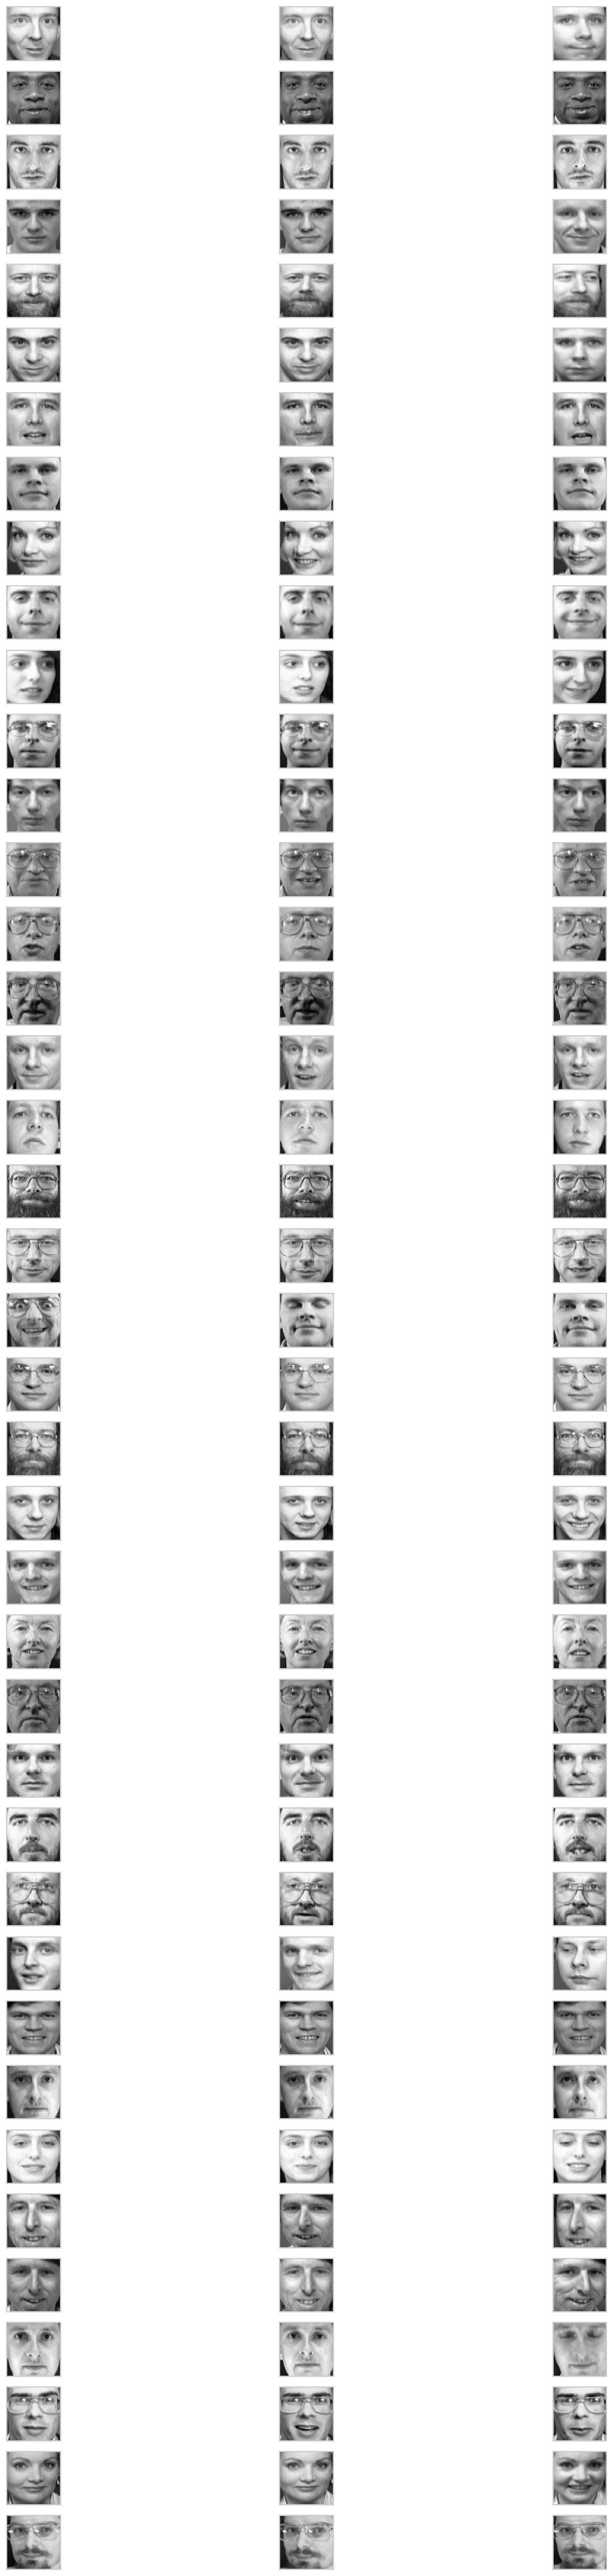

In [ ]:
kmeans = KMeans(40, n_init=3).fit(X_train)
knn = KNeighborsClassifier(3).fit(X_train, y_train)
fig, ax = plt.subplots(40, 3, figsize=(1, 50))

for i, center in enumerate(kmeans.cluster_centers_):
    inxs = knn.kneighbors([center], 3)[1][0]
    for j, inx in enumerate(inxs):
        ax[i, j].imshow(X_train[inx].reshape(64, 64), cmap='gray')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        ax[i, j].grid(False)

plt.show()

11. Continuing with the Olivetti faces dataset, train a classifier to predict which
person is represented in each picture, and evaluate it on the validation set. Next,
use k-means as a dimensionality reduction tool, and train a classifier on the
reduced set. Search for the number of clusters that allows the classifier to get
the best performance: what performance can you reach? What if you append the
features from the reduced set to the original features (again, searching for the
best number of clusters)?

In [204]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV
import pandas as pd
from sklearn.preprocessing import FunctionTransformer

In [216]:
forest_clf = RandomForestClassifier(random_state=42).fit(X_train_mini, y_train_mini)
y_val_pred = forest_clf.predict(X_val)
f1_score(y_val, y_val_pred, average='macro')

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/home/zdravko/Machine_Learning

1.0

In [217]:
y_test_pred = forest_clf.predict(X_test)
f1_score(y_test, y_test_pred, average='macro')

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/zdravko/Machine_Learning

0.9666666666666668

In [201]:
forest_pipe = Pipeline([
    ('kmeans', KMeans(random_state=42, n_init=3)),
    ('forest', RandomForestClassifier(random_state=42))
])

grid = {'kmeans__n_clusters': [22, 38, 39, 40, 42, 43, 44, 45, 46, 47, 48, 50]}
grid_search = GridSearchCV(forest_pipe, grid, scoring='f1_macro', cv=3).fit(X_train, y_train)

In [ ]:
pd.DataFrame(grid_search.cv_results_).sort_values('mean_test_score', ascending=False)

In [210]:
best_kmeans = KMeans(40, n_init=3, random_state=42).fit(X_train)

def stack_dist(X):
    dist = best_kmeans.transform(X)
    return np.hstack([X, dist])

func_trans = FunctionTransformer(stack_dist)

forest_pipe_with_dist = Pipeline([
    ('transformer', func_trans),
    ('forest', RandomForestClassifier(random_state=42))
])

forest_pipe_with_dist.fit(X_train_mini, y_train_mini)

,steps,"[('transformer', ...), ('forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,func,<function sta...x728618f5b100>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [211]:
y_val_pred = forest_pipe_with_dist.predict(X_val)
f1_score(y_val, y_val_pred, average='macro')

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/home/zdravko/Machine_Learning

1.0

In [212]:
y_test_pred = forest_pipe_with_dist.predict(X_test)
f1_score(y_test, y_test_pred, average='macro')

1.0

12. Train a Gaussian mixture model on the Olivetti faces dataset. To speed up the
algorithm, you should probably reduce the dataset’s dimensionality (e.g., use
PCA, preserving 99% of the variance). Use the model to generate some new
faces (using the sample() method), and visualize them (if you used PCA, you
will need to use its inverse_transform() method). Try to modify some images
(e.g., rotate, flip, darken) and see if the model can detect the anomalies (i.e.,
compare the output of the score_samples() method for normal images and for
anomalies).

In [218]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

In [ ]:
gm = GaussianMixture(40)
pca = PCA()

gm_pipe = Pipeline([
    ('pca', PCA(n_components=0.99, random_state=43)),
  kmeans = KMeans(22, random_state=42, n_init=2)
fig, ax = plt.subplots(figsize=(20, 18))
visualizer = SilhouetteVisualizer(kmeans, ax=ax).fit(X_train)
visualizer.show()  ('gm', GaussianMixture(40, random_state=41))
])

gm_pipe.fit(X_train_mini)

,steps,"[('pca', ...), ('gm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_components,0.99
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10


In [220]:
y_val_pred = gm_pipe.predict(X_val)
f1_score(y_val, y_val_pred, average='macro')

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/home/zdravko/Machine_Learning

0.025

In [221]:
grid = {
    'gm__n_components': list(range(22, 44))
}

gm_grid_search = GridSearchCV(gm_pipe, grid, scoring='f1_macro', cv=3).fit(X_train, y_train)

In [ ]:

pd.DataFrame(gm_grid_search.cv_results_).sort_values('mean_test_score', ascending=False)

In [ ]:
best_gm = gm_grid_search.best_estimator_

generated_faces = best_gm[1].sample(10)


/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:443: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


AttributeError: 'tuple' object has no attribute 'shape'

In [226]:
generated_faces[0].shape

(10, 242)

In [228]:
inv_generated_faces = best_gm[0].inverse_transform(generated_faces[0])
inv_generated_faces.shape

(10, 4096)

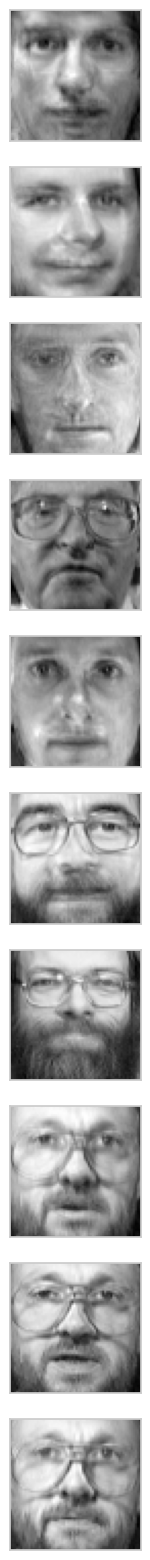

In [232]:
fig, ax = plt.subplots(10, 1, figsize=(50, 20)) 

for i, img in enumerate(inv_generated_faces):
    ax[i].imshow(img.reshape(64, 64), cmap='gray')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].grid(False)

plt.show()

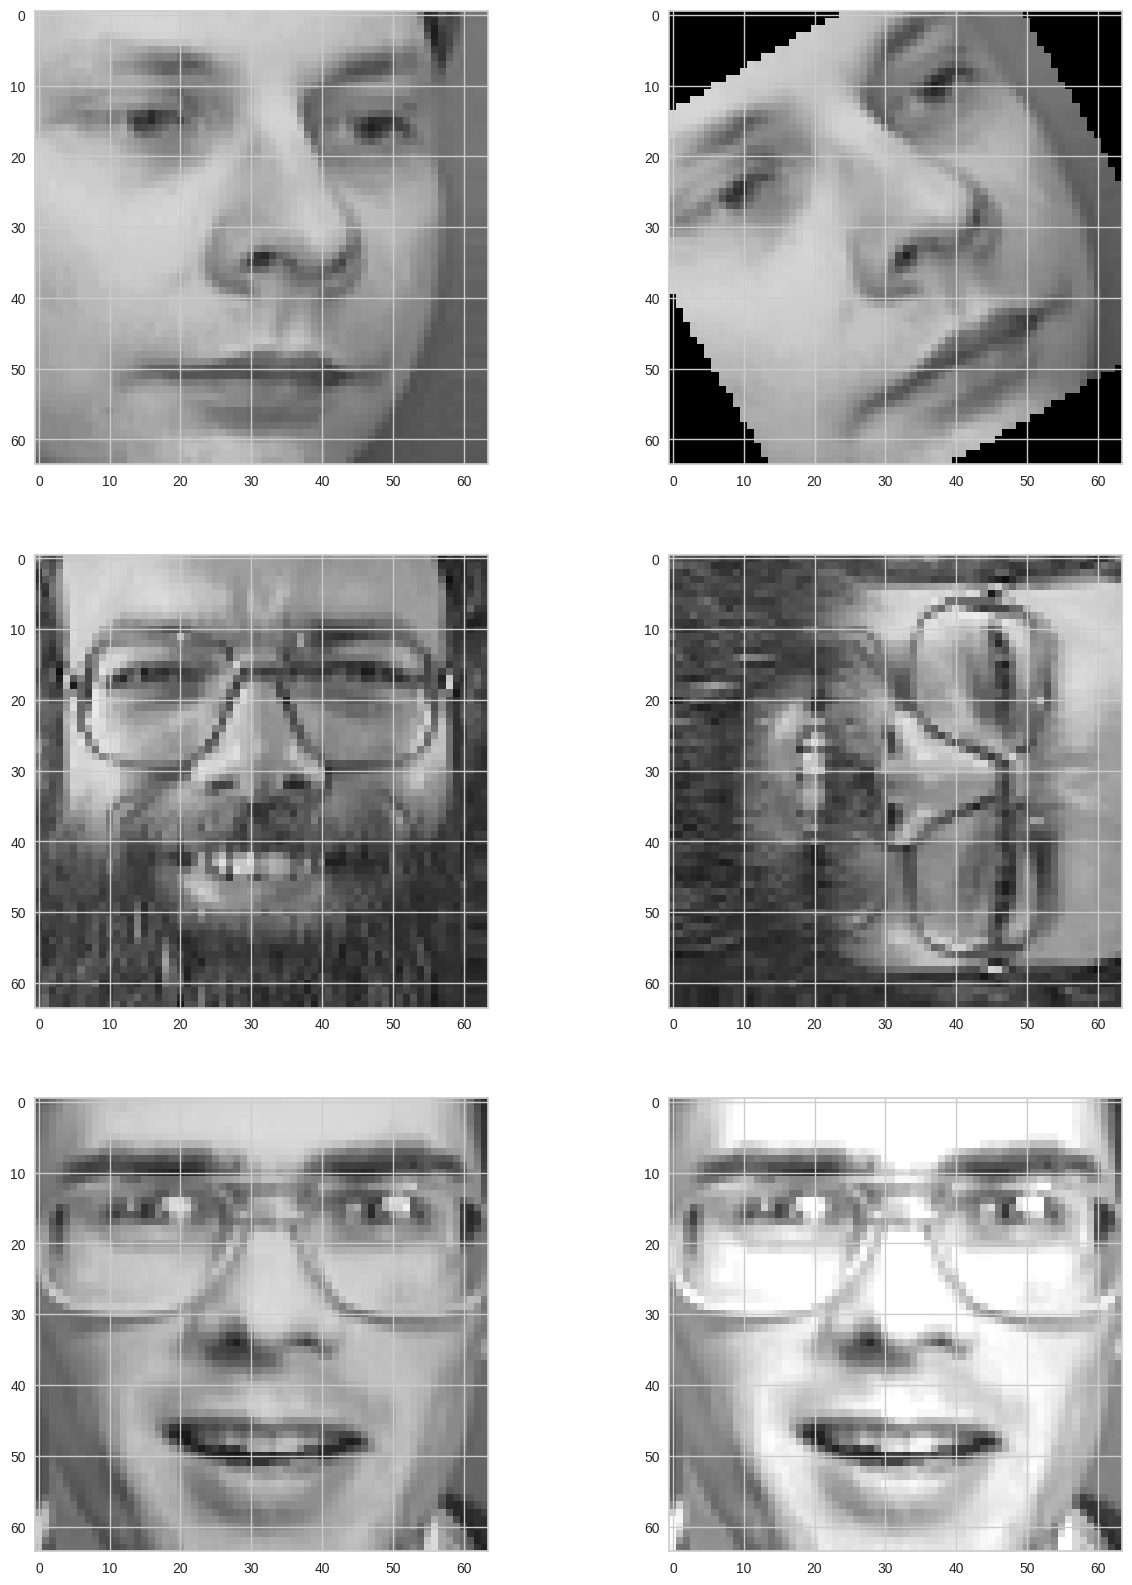

In [310]:
fig, ax = plt.subplots(3, 2, figsize=(15, 20))

def rotate_image(img, angle):
    from scipy.ndimage import rotate
    return rotate(img.reshape(64, 64), angle, reshape=False).ravel()

img1 = X[55]
plot_face(img1, ax[0, 0])
# ax[0, 1].imshow(rotate_image(img1, 30))
plot_face(rotate_image(img1, 30), ax[0, 1])

img2 = X[255]

plot_face(img2, ax[1, 0])
# ax[1, 1].imshow(rotate_image(img2, 270))
plot_face(rotate_image(img2, 270), ax[1, 1])

img3 = X[135]

def darken_image(img, factor=0.8):
    img = img.reshape(64, 64)
    img_new = img * factor
    return np.clip(img_new, 0, 1).ravel()

plot_face(img3, ax[2, 0])
# ax[2, 1].imshow(darken_image(img3.reshape(64, 64), 0.1))
plot_face(darken_image(img3, 1.3), ax[2, 1])

plt.show()

In [328]:
X_train_with_anomalies = X_train.copy()

for i in range(3):
    inxs = np.random.choice(X_train.shape[0], 5, replace=False)

    new_X = np.empty((5, 4096))
    if i == 0:
        rng = np.arange(20, 300)
        angles = np.random.choice(rng, 5, replace=False)
        for j, ang in enumerate(angles):
            new_X[j] = rotate_image(X_train[inxs[j]], ang)

    elif i == 1:
        angles = np.random.choice([90, 270], 5, replace=True)
        for j, ang in enumerate(angles):
            new_X[j] = rotate_image(X_train[inxs[j]], ang)

    else:
        factors = [0.2, 0.1, 0.8, 1.2, 1.5]
        np.random.shuffle(factors)
        for j, fac in enumerate(factors):
            new_X[j] = darken_image(X_train[inxs[j]], fac)

    X_train_with_anomalies = np.vstack([X_train_with_anomalies, new_X])


gen_anomalies = X_train_with_anomalies[-16:].copy()
np.random.shuffle(X_train_with_anomalies)

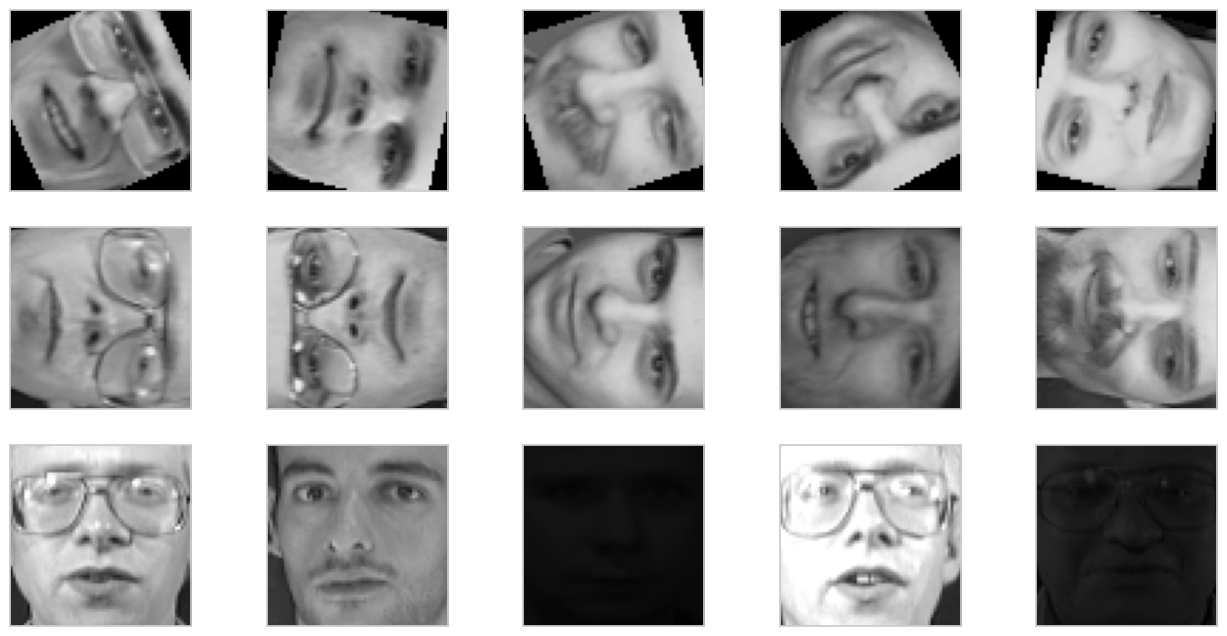

In [329]:
rows, cols = 3, 5
fig, ax = plt.subplots(rows, cols, figsize=(16, 8))

c = 1
b_flag = False
for i in range(rows):
    for j in range(cols):
        ax[i, j].imshow(gen_anomalies[c].reshape(64, 64), cmap='gray', vmin=0, vmax=1)
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        ax[i, j].grid(False)
        
        c += 1 

In [315]:
from sklearn.base import clone

best_gm_anom = clone(best_gm)
best_gm_anom.fit(X_train)

,steps,"[('pca', ...), ('gm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_components,0.99
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10


In [330]:
densities = best_gm_anom.score_samples(X_train_with_anomalies)
density_threshold = np.percentile(densities, 5)
anomalies = X_train_with_anomalies[densities < density_threshold]

In [331]:
anomalies.shape

(19, 4096)

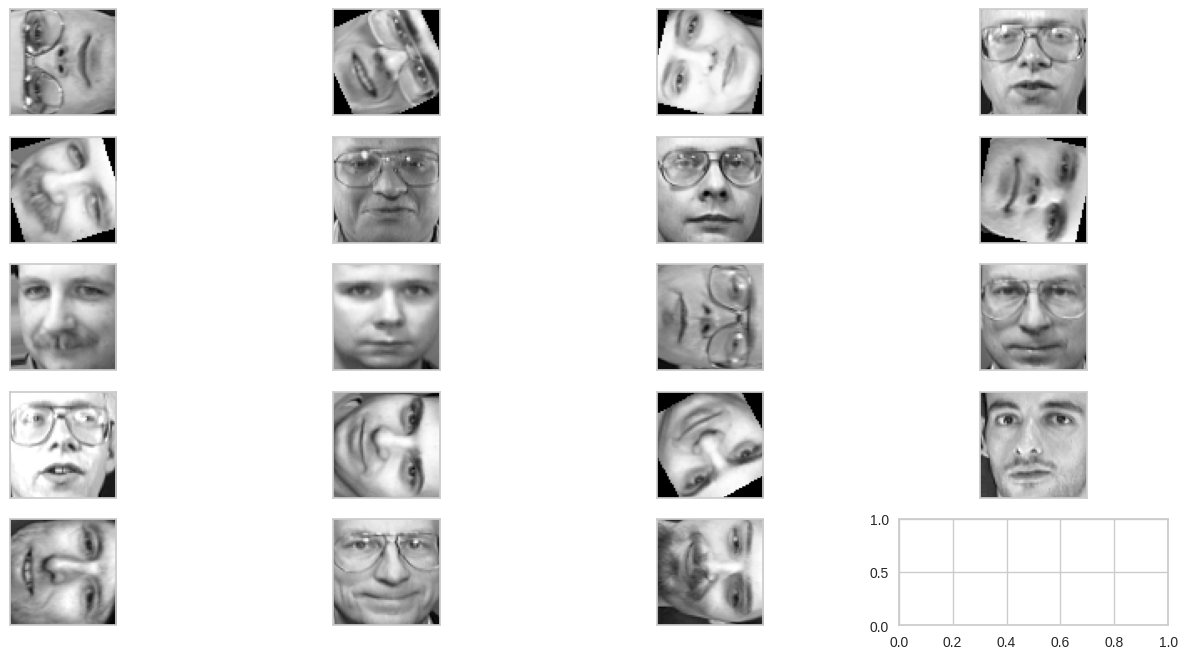

In [332]:
rows, cols = 5, 4
fig, ax = plt.subplots(rows, cols, figsize=(16, 8))

c = 0
b_flag = False
for i in range(rows):
    for j in range(cols):
        ax[i, j].imshow(anomalies[c].reshape(64, 64), cmap='gray')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        ax[i, j].grid(False)
        
        c += 1 
        if c == len(anomalies):
            b_flag = True
            break
    if b_flag:
        break

plt.show()

13. Some dimensionality reduction techniques can also be used for anomaly detec‐
tion. For example, take the Olivetti faces dataset and reduce it with PCA, preserv‐
ing 99% of the variance. Then compute the reconstruction error for each image.
Next, take some of the modified images you built in the previous exercise and
look at their reconstruction error: notice how much larger it is. If you plot a
reconstructed image, you will see why: it tries to reconstruct a normal face.

In [285]:
pca = PCA(0.99)
X_trans = pca.fit_transform(X)
X_reverse = pca.inverse_transform(X_trans)

print('l2:', np.linalg.norm(X - X_reverse, ord=2))
print('MSE:', np.mean((X - X_reverse) ** 2))

l2: 2.0591476
MSE: 0.00019257102


In [333]:
pca = clone(pca)
anomalies_trans = pca.fit_transform(gen_anomalies)
anomalies_reverse = pca.inverse_transform(anomalies_trans)

print('l2:', np.linalg.norm(gen_anomalies - anomalies_reverse, ord=2))
print('MSE:', np.mean((gen_anomalies - anomalies_reverse) ** 2))

l2: 3.822160831558201
MSE: 0.00024177881780624726


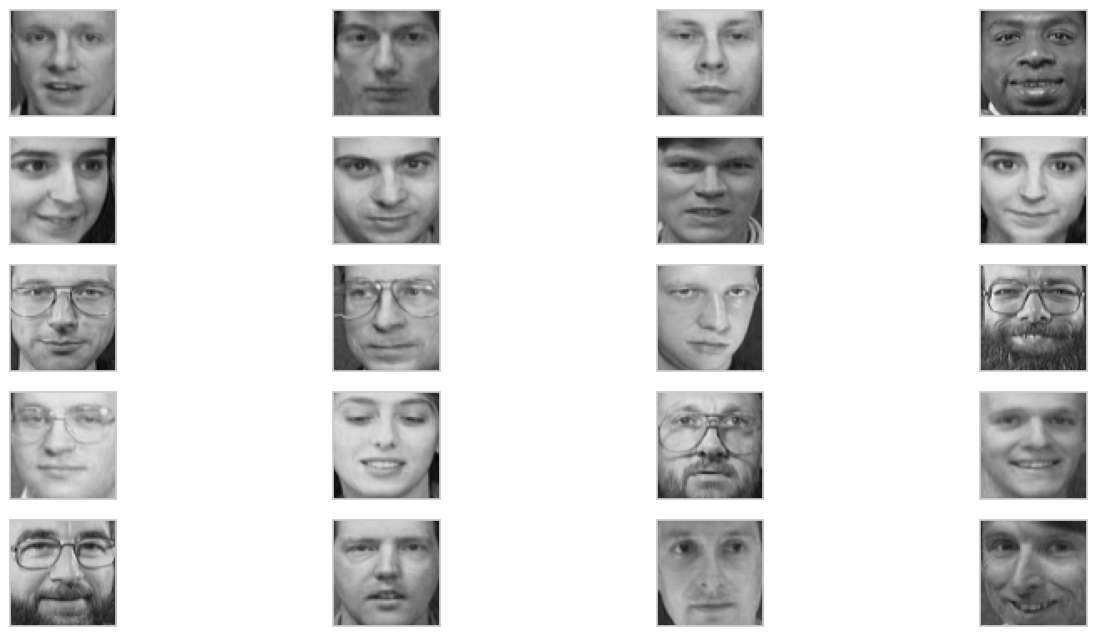

In [335]:
pca = PCA(0.99)
X_trans = pca.fit_transform(X)
X_reverse = pca.inverse_transform(X_trans)

rows, cols = 5, 4
fig, ax = plt.subplots(rows, cols, figsize=(16, 8))

c = 0
b_flag = False
for i in range(rows):
    for j in range(cols):
        ax[i, j].imshow(X_reverse[c].reshape(64, 64), cmap='gray', vmin=0, vmax=1)
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        ax[i, j].grid(False)
        c += 1
        
plt.show()